## K-Nearest Neighbours

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

### Exploring


In [59]:
df = pd.read_csv("Zoo.csv")
df.head()

,animal name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
0,aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,bass,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1


In [60]:
df.shape

(101, 18)

In [61]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   animal name  101 non-null    str  
 1   hair         101 non-null    int64
 2   feathers     101 non-null    int64
 3   eggs         101 non-null    int64
 4   milk         101 non-null    int64
 5   airborne     101 non-null    int64
 6   aquatic      101 non-null    int64
 7   predator     101 non-null    int64
 8   toothed      101 non-null    int64
 9   backbone     101 non-null    int64
 10  breathes     101 non-null    int64
 11  venomous     101 non-null    int64
 12  fins         101 non-null    int64
 13  legs         101 non-null    int64
 14  tail         101 non-null    int64
 15  domestic     101 non-null    int64
 16  catsize      101 non-null    int64
 17  type         101 non-null    int64
dtypes: int64(17), str(1)
memory usage: 14.9 KB


In [62]:
df.describe()

,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
count,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000
mean,0.425743,0.198020,0.584158,0.405941,0.237624,0.356436,0.554455,0.603960,0.821782,0.792079,0.079208,0.168317,2.841584,0.742574,0.128713,0.435644,2.831683
std,0.496921,0.400495,0.495325,0.493522,0.427750,0.481335,0.499505,0.491512,0.384605,0.407844,0.271410,0.376013,2.033385,0.439397,0.336552,0.498314,2.102709
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,1.000000
50%,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,4.000000,1.000000,0.000000,0.000000,2.000000
75%,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,4.000000,1.000000,0.000000,1.000000,4.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,8.000000,1.000000,1.000000,1.000000,7.000000


In [63]:
df.isnull().sum()

animal name    0
hair           0
feathers       0
eggs           0
milk           0
airborne       0
aquatic        0
predator       0
toothed        0
backbone       0
breathes       0
venomous       0
fins           0
legs           0
tail           0
domestic       0
catsize        0
type           0
dtype: int64

In [64]:
#Checking duplicate rows
print("Duplicate rows:", df.duplicated().sum())
#Removing duplicates if any
df = df.drop_duplicates()

Duplicate rows: 0


### Visualizations

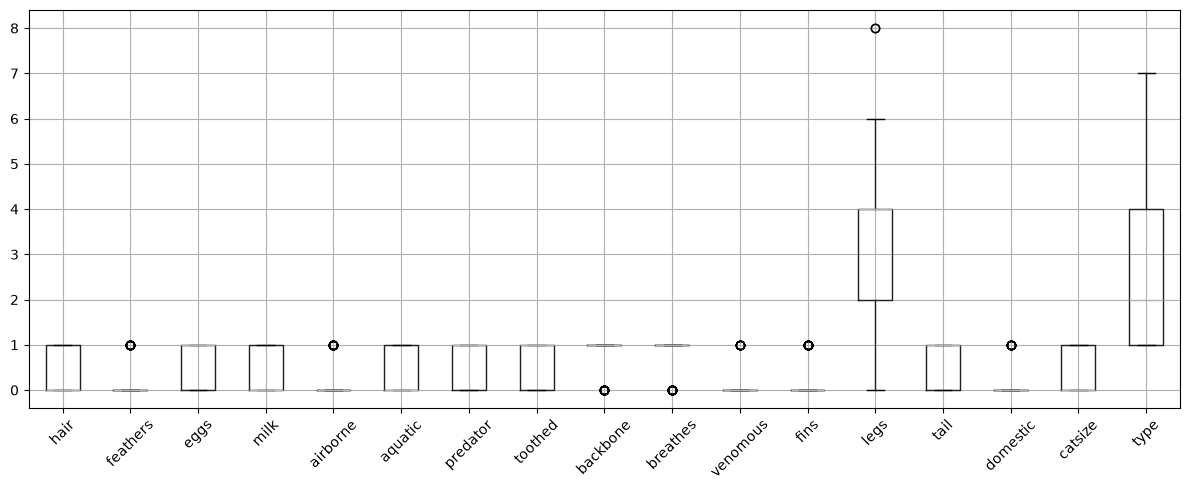

In [81]:
# Boxplot 
plt.figure(figsize=(12,5))
df.drop(columns=["animal name"]).boxplot(rot=45)
plt.tight_layout()
plt.show()

* Most features are binary, so their values show very little variation.
* No missing values are evident from the distributions in the boxplot.
* The legs feature has the highest spread because animals can have different numbers of legs.
* The type feature also shows a wider distribution since it contains multiple animal categories.
* A few outliers are present in the legs feature, representing animals with uncommon leg counts.
* Outlier treatment is not necessary because the dataset mainly consists of binary features.

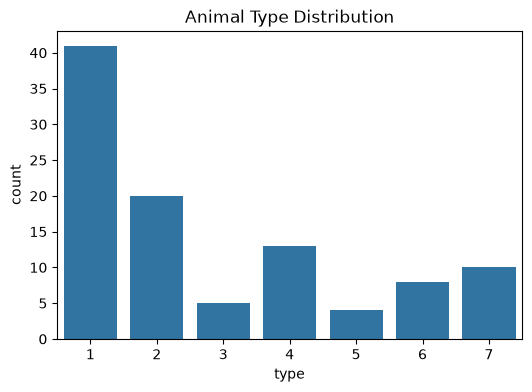

In [66]:
# Count plot of animal classes
plt.figure(figsize=(6,4))
sns.countplot(x="type", data=df)
plt.title("Animal Type Distribution")
plt.show()

* Animal type 1 has the highest number of samples, making it the dominant class in the dataset.
* Animal types 3 and 5 have the fewest samples compared to the other classes.
* The distribution of animal types is imbalanced, as some classes contain significantly more records than others.
* Most animal classes have relatively small sample sizes except for types 1 and 2.
* The class imbalance should be considered while evaluating the performance of the KNN classifier.

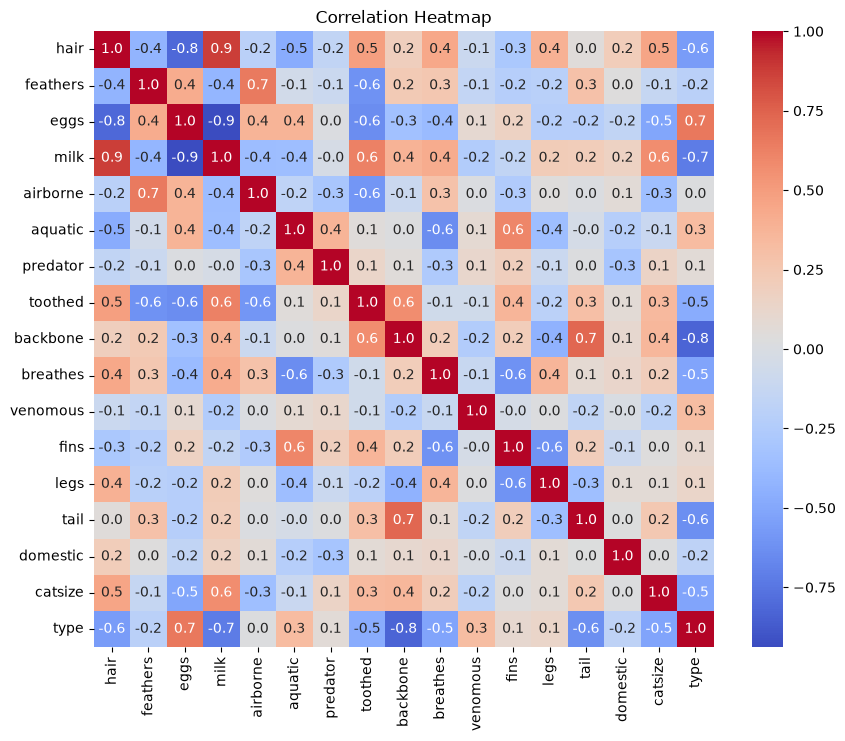

In [84]:
#Correlation 
plt.figure(figsize=(10,8))
sns.heatmap(df.drop(columns=["animal name"]).corr(), annot=True, fmt=".1f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

* Most features show weak to moderate correlations, indicating that they provide different information about the animals.
* Hair and milk have a strong positive correlation, as mammals typically possess both characteristics.
* Feathers and eggs show a positive correlation because birds generally lay eggs.
* Backbone and toothed exhibit a positive relationship, suggesting these traits often occur together.
* Hair and eggs have a strong negative correlation since mammals usually do not lay eggs.
* No pair of features shows perfect correlation, indicating that each feature contributes useful information for classification.

### Preprocessing

In [ ]:
X = df.drop(columns=["animal name","type"])
y = df["type"]
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [69]:
#Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test) #To avoid data leakage during fit

In [70]:
#Finding the best K
accuracy = []

for k in range(1,16):
    model = KNeighborsClassifier(n_neighbors=k, metric="euclidean")
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    accuracy.append(accuracy_score(y_test, pred))

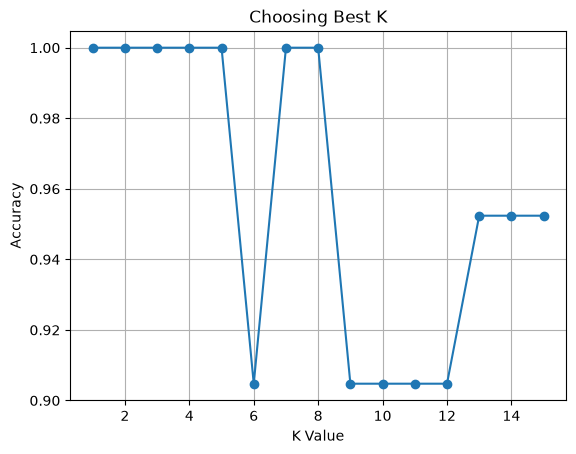

In [71]:
plt.plot(range(1,16), accuracy, marker="o")
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("Choosing Best K")
plt.grid(True)
plt.show()

* The classifier achieves the highest accuracy of 100% for K values of 1–5 and again for K values of 7–8.
* Accuracy drops noticeably at K = 6 and for K values between 9 and 12.
* The accuracy improves slightly for K values of 13–15 but does not reach the maximum value.
* Smaller K values provide better classification performance for this dataset.
* Based on the accuracy plot, K = 5 is a suitable choice as it achieves maximum accuracy while reducing the risk of overfitting compared to K = 1.

In [ ]:
best_k = 5

In [ ]:
#Final Model
knn = KNeighborsClassifier(n_neighbors=best_k, metric="euclidean")
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

In [74]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred, average="weighted"))
print("F1 Score :", f1_score(y_test, y_pred, average="weighted"))

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


In [75]:
print("\nClassification Report\n")
print(classification_report(y_test, y_pred))


Classification Report

              precision    recall  f1-score   support

           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         4
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         1
           6       1.00      1.00      1.00         2
           7       1.00      1.00      1.00         2

    accuracy                           1.00        21
   macro avg       1.00      1.00      1.00        21
weighted avg       1.00      1.00      1.00        21



In [76]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[8 0 0 0 0 0 0]
 [0 4 0 0 0 0 0]
 [0 0 1 0 0 0 0]
 [0 0 0 3 0 0 0]
 [0 0 0 0 1 0 0]
 [0 0 0 0 0 2 0]
 [0 0 0 0 0 0 2]]


In [ ]:
#Decision Boundary (using first two features, hair and feathers)
X_vis = X.iloc[:, :2]
X_train_v, X_test_v, y_train_v, y_test_v = train_test_split(X_vis,y,test_size=0.2,random_state=42,stratify=y)

scaler = StandardScaler()
X_train_v = scaler.fit_transform(X_train_v)
X_test_v = scaler.transform(X_test_v)

In [78]:
model = KNeighborsClassifier(n_neighbors=best_k)
model.fit(X_train_v, y_train_v)

x_min, x_max = X_train_v[:,0].min()-1, X_train_v[:,0].max()+1
y_min, y_max = X_train_v[:,1].min()-1, X_train_v[:,1].max()+1

xx, yy = np.meshgrid(np.arange(x_min,x_max,0.02),np.arange(y_min,y_max,0.02))

In [79]:
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

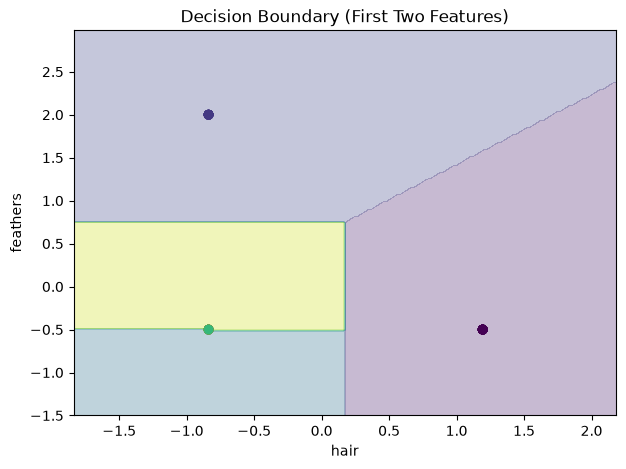

In [80]:
plt.figure(figsize=(7,5))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_train_v[:,0], X_train_v[:,1], c=y_train_v)
plt.title("Decision Boundary (First Two Features)")
plt.xlabel(X.columns[0])
plt.ylabel(X.columns[1])
plt.show()

* The graph shows how the KNN classifier divides the feature space into different regions based on the first two features, hair and feathers.
* Each colored region represents the class that the model would predict for any new data point falling within that region.
* The boundary between two colored regions indicates where the predicted class changes.
* The training samples are plotted as colored points and lie within or very close to their corresponding decision regions.
* Only the first two features are used for visualization, so the decision boundary does not represent the full 16-feature classification performed by the final KNN model.
* The clear separation between the colored regions suggests that the selected features help distinguish different animal classes effectively.

### Interview Questions

(Q) What are the key hyperparameters in KNN?
- Number of neighbours (K)
- Distance metric
- Weight function (uniform/distance)
- Algorithm (auto, ball_tree, kd_tree, brute)

(Q)  What distance metrics can be used in KNN?
- Euclidean
- Manhattan
- Minkowski
- Chebyshev
- Hamming (for binary data)